# Home Price Prediction using Linear Regression
# **Objective:** To predict real estate prices based on features like square footage, number of bedrooms, etc.
# **Techniques:** Data Cleaning, Feature Engineering, Linear Regression.

# pandas Data Exploration and Pre-processing

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\ML_Projects\ML_Project_1.txt")
data

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,03/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.80140,144.99580,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,03/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.79960,144.99840,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,04/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,04/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.81140,145.01160,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,04/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Yarraville,13 Burns St,4,h,1480000.0,PI,Jas,24/02/2018,6.3,3013.0,...,1.0,3.0,593.0,NaN,NaN,Maribyrnong City Council,-37.81053,144.88467,Western Metropolitan,6543.0
34853,Yarraville,29A Murray St,2,h,888000.0,SP,Sweeney,24/02/2018,6.3,3013.0,...,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,Western Metropolitan,6543.0
34854,Yarraville,147A Severn St,2,t,705000.0,S,Jas,24/02/2018,6.3,3013.0,...,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,Western Metropolitan,6543.0
34855,Yarraville,12/37 Stephen St,3,h,1140000.0,SP,hockingstuart,24/02/2018,6.3,3013.0,...,NaN,NaN,NaN,NaN,NaN,Maribyrnong City Council,NaN,NaN,Western Metropolitan,6543.0


In [3]:
data.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [4]:
data.head(1)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,03/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0


In [5]:
data.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


In [6]:
data.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,03/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,03/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,04/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,04/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,04/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [7]:
data.drop(["Address","Date","Postcode","YearBuilt","Lattitude","Longtitude"],axis=1,inplace=True) # not help in model accracy

In [8]:
data.head(2)

,Suburb,Rooms,Type,Price,Method,SellerG,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,CouncilArea,Regionname,Propertycount
0,Abbotsford,2,h,NaN,SS,Jellis,2.5,2.0,1.0,1.0,126.0,NaN,Yarra City Council,Northern Metropolitan,4019.0
1,Abbotsford,2,h,1480000.0,S,Biggin,2.5,2.0,1.0,1.0,202.0,NaN,Yarra City Council,Northern Metropolitan,4019.0


In [9]:
data.isnull().sum() # check null values

Suburb               0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Distance             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
CouncilArea          3
Regionname           3
Propertycount        3
dtype: int64

In [10]:
data[["Propertycount","Distance","Bedroom2","Bathroom","Car"]] = data[["Propertycount","Distance","Bedroom2","Bathroom","Car"]].fillna(0)

In [11]:
data.isnull().sum()

Suburb               0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Distance             0
Bedroom2             0
Bathroom             0
Car                  0
Landsize         11810
BuildingArea     21115
CouncilArea          3
Regionname           3
Propertycount        0
dtype: int64

In [12]:
data1 = data.copy()

In [13]:
data["Landsize"] = data["Landsize"].fillna(data["Landsize"].mean())
data["BuildingArea"] = data["BuildingArea"].fillna(data["BuildingArea"].mean())

In [14]:
data.isnull().sum()

Suburb              0
Rooms               0
Type                0
Price            7610
Method              0
SellerG             0
Distance            0
Bedroom2            0
Bathroom            0
Car                 0
Landsize            0
BuildingArea        0
CouncilArea         3
Regionname          3
Propertycount       0
dtype: int64

In [15]:
data["Method"].unique()

array(['SS', 'S', 'VB', 'SP', 'PI', 'SN', 'W', 'PN', 'SA'], dtype=object)

In [16]:
data.head()

,Suburb,Rooms,Type,Price,Method,SellerG,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,CouncilArea,Regionname,Propertycount
0,Abbotsford,2,h,NaN,SS,Jellis,2.5,2.0,1.0,1.0,126.0,160.2564,Yarra City Council,Northern Metropolitan,4019.0
1,Abbotsford,2,h,1480000.0,S,Biggin,2.5,2.0,1.0,1.0,202.0,160.2564,Yarra City Council,Northern Metropolitan,4019.0
2,Abbotsford,2,h,1035000.0,S,Biggin,2.5,2.0,1.0,0.0,156.0,79.0000,Yarra City Council,Northern Metropolitan,4019.0
3,Abbotsford,3,u,NaN,VB,Rounds,2.5,3.0,2.0,1.0,0.0,160.2564,Yarra City Council,Northern Metropolitan,4019.0
4,Abbotsford,3,h,1465000.0,SP,Biggin,2.5,3.0,2.0,0.0,134.0,150.0000,Yarra City Council,Northern Metropolitan,4019.0


In [17]:
data1

,Suburb,Rooms,Type,Price,Method,SellerG,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,CouncilArea,Regionname,Propertycount
0,Abbotsford,2,h,NaN,SS,Jellis,2.5,2.0,1.0,1.0,126.0,NaN,Yarra City Council,Northern Metropolitan,4019.0
1,Abbotsford,2,h,1480000.0,S,Biggin,2.5,2.0,1.0,1.0,202.0,NaN,Yarra City Council,Northern Metropolitan,4019.0
2,Abbotsford,2,h,1035000.0,S,Biggin,2.5,2.0,1.0,0.0,156.0,79.0,Yarra City Council,Northern Metropolitan,4019.0
3,Abbotsford,3,u,NaN,VB,Rounds,2.5,3.0,2.0,1.0,0.0,NaN,Yarra City Council,Northern Metropolitan,4019.0
4,Abbotsford,3,h,1465000.0,SP,Biggin,2.5,3.0,2.0,0.0,134.0,150.0,Yarra City Council,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Yarraville,4,h,1480000.0,PI,Jas,6.3,4.0,1.0,3.0,593.0,NaN,Maribyrnong City Council,Western Metropolitan,6543.0
34853,Yarraville,2,h,888000.0,SP,Sweeney,6.3,2.0,2.0,1.0,98.0,104.0,Maribyrnong City Council,Western Metropolitan,6543.0
34854,Yarraville,2,t,705000.0,S,Jas,6.3,2.0,1.0,2.0,220.0,120.0,Maribyrnong City Council,Western Metropolitan,6543.0
34855,Yarraville,3,h,1140000.0,SP,hockingstuart,6.3,0.0,0.0,0.0,NaN,NaN,Maribyrnong City Council,Western Metropolitan,6543.0


### Encode Data with get dummy 

In [18]:
data1 = pd.get_dummies(data1, drop_first=True)

In [19]:
data1 = data.copy()

In [20]:
data = pd.get_dummies(data, drop_first=True)

In [21]:
data.columns

Index(['Rooms', 'Price', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'Propertycount', 'Suburb_Aberfeldie',
       ...
       'CouncilArea_Wyndham City Council', 'CouncilArea_Yarra City Council',
       'CouncilArea_Yarra Ranges Shire Council', 'Regionname_Eastern Victoria',
       'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria',
       'Regionname_South-Eastern Metropolitan',
       'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan',
       'Regionname_Western Victoria'],
      dtype='object', length=795)

# ML Working with Model

### Split data in x & y with train test split

In [22]:
data = data.dropna(subset=["Price"])
x = data.drop("Price",axis=1)
y = data["Price"]

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

### Model train and check accuracy

In [25]:
model = LinearRegression()

In [26]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
model.score(x_train,y_train)

0.6848643213359213

In [28]:
model.score(x_test,y_test)

0.6533666160275944

### Regularization Method

In [29]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=50)
ridge.fit(x_train,y_train)

print("Ridge Train Score:",ridge.score(x_train,y_train))
print("Ridge Test Score:",ridge.score(x_test,y_test))

Ridge Train Score: 0.6696659192034811
Ridge Test Score: 0.6403539844898167


In [30]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=50)
lasso.fit(x_train,y_train)

print("Lasso Train Score:",lasso.score(x_train,y_train))
print("Lasso Test Score:",lasso.score(x_test,y_test))

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.117e+14, tolerance: 8.882e+11
  model = cd_fast.enet_coordinate_descent(


Lasso Train Score: 0.6804803622121499
Lasso Test Score: 0.652631525157412


In [31]:
model.coef_

array([ 2.63925573e+05, -4.63978213e+04, -8.51983899e+04,  1.30454814e+05,
        4.18859355e+04,  8.56573587e+00,  3.62301716e+01,  6.58825935e+00,
        2.39495623e+05, -5.48762738e+04, -6.67232498e+04,  2.68545044e+05,
        1.07751176e+05,  2.20734678e+05,  1.72690800e+05, -1.14847672e+05,
       -1.47263823e+05, -5.84067674e+04,  5.12614083e+04, -1.28875685e+05,
       -2.39529529e+05, -2.05317772e+04,  5.45514825e+04, -2.35041134e+05,
       -7.32640972e+04, -2.42702683e+05, -6.82775863e-08,  1.71169613e+05,
       -1.13737654e+05,  3.45257527e+03, -2.05596736e+05,  8.86089246e+04,
        6.16797348e+04,  1.81491264e+05,  2.27709272e+04,  1.92240827e+05,
       -4.91854735e-09, -2.07288139e+05,  8.52283775e+04, -4.16337030e+04,
       -3.24071949e+04,  2.22798350e+05,  1.69877650e+05, -8.36834861e+04,
       -7.28160235e+04,  2.17342468e+05,  1.49078688e+05,  8.32369551e-08,
        2.02971624e+05, -6.43283192e+03, -1.03308599e+04,  2.99701194e+05,
       -1.14534152e+05, -

In [32]:
model.intercept_

np.float64(668678.8049508755)

### Model Evalution

In [33]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

In [34]:
ypri = model.predict(x_test)
ypri

array([ 872377.97183368,  391381.26403546, 1226388.39828532, ...,
       1412892.80746423,  968543.47446127, 1472720.25215341])

In [35]:
mean_squared_error(y_test,ypri)

148119808400.73987

In [36]:
mean_absolute_error(y_test,ypri)

233285.19002793514

In [37]:
root_mean_squared_error(y_test,ypri)

384863.363287206

In [38]:
r2_score(y_test,ypri)

0.6533666160275944

# extra

In [39]:
from sklearn.preprocessing import PolynomialFeatures

In [40]:
poly = PolynomialFeatures(degree=2)


In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(x_train, y_train)

print("Train Score:", rf.score(x_train, y_train))
print("Test Score:", rf.score(x_test, y_test))

Train Score: 0.9640941804086686
Test Score: 0.7752623963678684


In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(x_train, y_train)

print("Train Score:", gb.score(x_train, y_train))
print("Test Score:", gb.score(x_test, y_test))

Train Score: 0.7619618137377211
Test Score: 0.7274825172390254


In [43]:
data

,Rooms,Price,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Propertycount,Suburb_Aberfeldie,...,CouncilArea_Wyndham City Council,CouncilArea_Yarra City Council,CouncilArea_Yarra Ranges Shire Council,Regionname_Eastern Victoria,Regionname_Northern Metropolitan,Regionname_Northern Victoria,Regionname_South-Eastern Metropolitan,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria
1,2,1480000.0,2.5,2.0,1.0,1.0,202.000000,160.2564,4019.0,False,...,False,True,False,False,True,False,False,False,False,False
2,2,1035000.0,2.5,2.0,1.0,0.0,156.000000,79.0000,4019.0,False,...,False,True,False,False,True,False,False,False,False,False
4,3,1465000.0,2.5,3.0,2.0,0.0,134.000000,150.0000,4019.0,False,...,False,True,False,False,True,False,False,False,False,False
5,3,850000.0,2.5,3.0,2.0,1.0,94.000000,160.2564,4019.0,False,...,False,True,False,False,True,False,False,False,False,False
6,4,1600000.0,2.5,3.0,1.0,2.0,120.000000,142.0000,4019.0,False,...,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,4,1480000.0,6.3,4.0,1.0,3.0,593.000000,160.2564,6543.0,False,...,False,False,False,False,False,False,False,False,True,False
34853,2,888000.0,6.3,2.0,2.0,1.0,98.000000,104.0000,6543.0,False,...,False,False,False,False,False,False,False,False,True,False
34854,2,705000.0,6.3,2.0,1.0,2.0,220.000000,120.0000,6543.0,False,...,False,False,False,False,False,False,False,False,True,False
34855,3,1140000.0,6.3,0.0,0.0,0.0,593.598993,160.2564,6543.0,False,...,False,False,False,False,False,False,False,False,True,False


In [44]:
import matplotlib.pyplot as plt

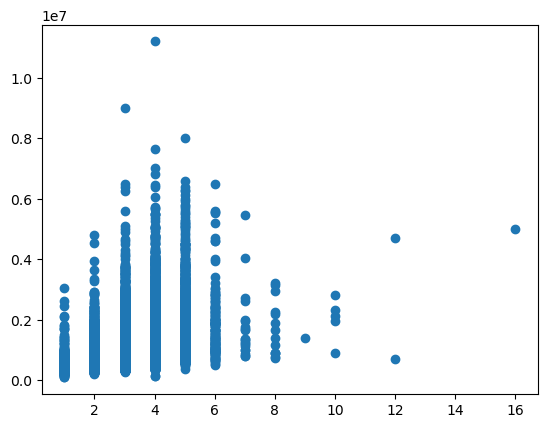

In [45]:
plt.scatter(data["Rooms"],data["Price"])

array([[<Axes: title={'center': 'Rooms'}>,
        <Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Distance'}>],
       [<Axes: title={'center': 'Bedroom2'}>,
        <Axes: title={'center': 'Bathroom'}>,
        <Axes: title={'center': 'Car'}>],
       [<Axes: title={'center': 'Landsize'}>,
        <Axes: title={'center': 'BuildingArea'}>,
        <Axes: title={'center': 'Propertycount'}>]], dtype=object)

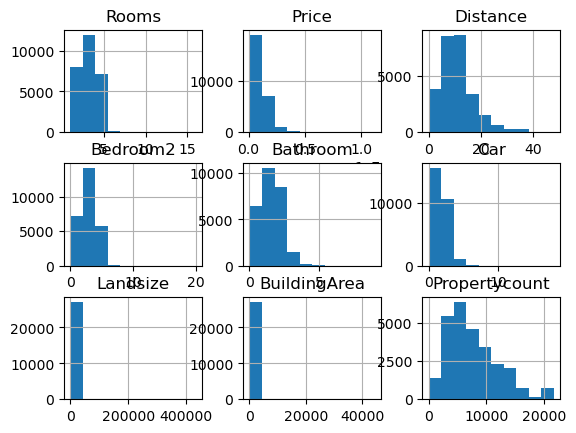

In [46]:
data.hist()